# Dynex SDK - Complex Native Gate Circuit Example

First we import the required packages:

In [1]:
from pennylane import numpy as np
import pennylane as qml
from dynex import DynexConfig, ComputeBackend, DynexCircuit

config = DynexConfig(compute_backend=ComputeBackend.QPU, qpu_model="apollo_rc1", use_notebook_output=True)

We define our circuit:

In [2]:
params = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6])
wires = 12


def Complex2(params):
    for i in range(12):
        qml.Hadamard(wires=i)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[2, 3])
    qml.CNOT(wires=[4, 5])
    qml.CNOT(wires=[6, 7])
    qml.CNOT(wires=[8, 9])
    qml.CNOT(wires=[10, 11])
    qml.RX(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.RZ(params[2], wires=2)
    qml.RX(params[3], wires=3)
    qml.RY(params[4], wires=4)
    qml.RZ(params[5], wires=5)
    qml.RX(params[6], wires=6)
    qml.RY(params[7], wires=7)
    qml.RZ(params[8], wires=8)
    qml.RX(params[9], wires=9)
    qml.RY(params[10], wires=10)
    qml.RZ(params[11], wires=11)
    qml.CZ(wires=[0, 2])
    qml.CRZ(params[12], wires=[1, 3])
    qml.Toffoli(wires=[4, 5, 6])
    qml.SWAP(wires=[7, 8])
    qml.SWAP(wires=[9, 10])
    qml.CRZ(params[13], wires=[11, 0])
    qml.CRY(params[14], wires=[1, 2])
    qml.CRX(params[15], wires=[3, 4])
    qml.Toffoli(wires=[5, 6, 7])
    qml.SWAP(wires=[8, 9])
    return qml.state()

We draw the circuit:

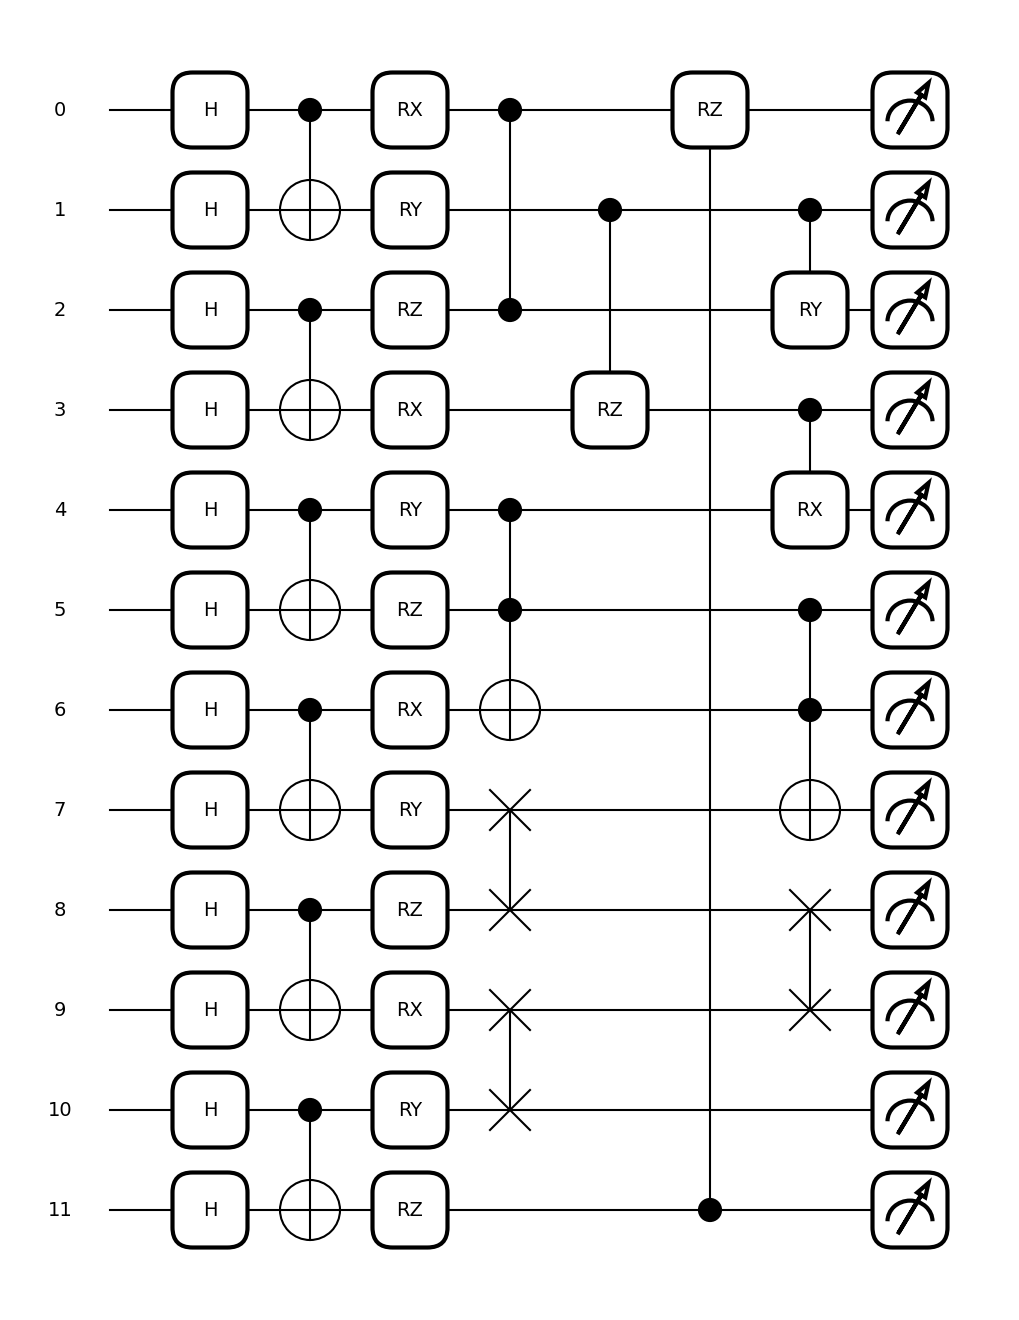

In [3]:
# draw circuit:
_ = qml.draw_mpl(Complex2, style="black_white")(params)

We execute and measure the circuit on the Dynex platform:

In [4]:
# Execute the circuit on Dynex:
dynex_circuit = DynexCircuit(config=config)
measure = dynex_circuit.execute(Complex2, params, wires, method="measure", num_reads=10,
                          integration_steps=100, shots=1)
print("Mesaure:", measure)

INFO: [DYNEX-APOLLO-RC1] Executing PennyLane quantum circuit
INFO: [DYNEX-APOLLO-RC1] Sampler initialised
INFO: [DYNEX-APOLLO-RC1] Apollo QPU chip: apollo_rc1
INFO: [DYNEX-APOLLO-RC1] Settings: num_reads=10, shots=1, annealing_time=100
INFO: [DYNEX-APOLLO-RC1] Submitting the job to Dynex.
INFO: [DYNEX-APOLLO-RC1] SUCCESS: Job created successfully (job_id=7409)
INFO: [DYNEX-APOLLO-RC1] feed_dict: {'cos_crx_3_4': 0.6967067093471654, 'cos_cry_1_2': 0.7316888688738209, 'cos_crz_11_0': 0.7648421872844885, 'cos_crz_1_3': 0.7960837985490559, 'cos_rx_0': 0.9987502603949663, 'cos_rx_3': 0.9800665778412416, 'cos_rx_6': 0.9393727128473789, 'cos_rx_9': 0.8775825618903728, 'cos_ry_1': 0.9950041652780258, 'cos_ry_10': 0.8525245220595057, 'cos_ry_4': 0.9689124217106447, 'cos_ry_7': 0.9210609940028851, 'cos_rz_11': 0.8253356149096783, 'cos_rz_2': 0.9887710779360422, 'cos_rz_5': 0.955336489125606, 'cos_rz_8': 0.9004471023526769, 'sin_crx_3_4': 0.7173560908995228, 'sin_cry_1_2': 0.6816387600233341, 'sin

Mesaure: [0 1 0 0 1 0 0 0 1 0 0 0]
